In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import cv2
from sklearn.metrics import roc_curve, auc

In [ ]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 8        
EPOCHS = 20

DATA_DIR = "data"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "validation"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 9600 images belonging to 2 classes.
Found 2400 images belonging to 2 classes.


In [ ]:
print("Class mapping:", train_gen.class_indices)

Class mapping: {'Anemic': 0, 'Healthy': 1}


In [6]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze base model

In [7]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

In [10]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

C:\Users\mehka\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.6728 - loss: 0.6501

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 634s 511ms/step - accuracy: 0.7071 - loss: 0.6022 - val_accuracy: 0.7817 - val_loss: 0.4882 - learning_rate: 1.0000e-04
Epoch 2/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.7279 - loss: 0.5593

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 570s 475ms/step - accuracy: 0.7332 - loss: 0.5465 - val_accuracy: 0.8008 - val_loss: 0.4467 - learning_rate: 1.0000e-04
Epoch 3/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7565 - loss: 0.5066

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1715s 1s/step - accuracy: 0.7506 - loss: 0.5077 - val_accuracy: 0.8092 - val_loss: 0.4246 - learning_rate: 1.0000e-04
Epoch 4/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.7686 - loss: 0.4828

...

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1640s 1s/step - accuracy: 0.7862 - loss: 0.4454 - val_accuracy: 0.8171 - val_loss: 0.3913 - learning_rate: 1.0000e-04
Epoch 10/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7907 - loss: 0.4328

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1311s 1s/step - accuracy: 0.7905 - loss: 0.4363 - val_accuracy: 0.8200 - val_loss: 0.3904 - learning_rate: 1.0000e-04
Epoch 11/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.7952 - loss: 0.4258

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 487s 405ms/step - accuracy: 0.7912 - loss: 0.4301 - val_accuracy: 0.8171 - val_loss: 0.3900 - learning_rate: 1.0000e-04
Epoch 12/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.7930 - loss: 0.4293

1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1046s 872ms/step - accuracy: 0.7934 - loss: 0.4346 - val_accuracy: 0.8171 - val_loss: 0.3799 - learning_rate: 1.0000e-04
Epoch 13/20
  57/1200 ━━━━━━━━━━━━━━━━━━━━ 6:42 352ms/step - accuracy: 0.8391 - loss: 0.4105

KeyboardInterrupt: 

In [11]:
# base_model.trainable = True

# # Freeze lower layers, train only top layers
# for layer in base_model.layers[:-40]:
#     layer.trainable = False

In [12]:
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-5),
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )

In [ ]:
# history_finetune = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=5,
#     callbacks=callbacks
# )

In [17]:
model = load_model("best_model.h5")

In [18]:
model.save("final_model.h5")

In [ ]:
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

In [19]:
loss, acc = model.evaluate(val_gen)
print(f"Validation Accuracy: {acc * 100:.2f}%")

300/300 ━━━━━━━━━━━━━━━━━━━━ 87s 260ms/step - accuracy: 0.8171 - loss: 0.3799
Validation Accuracy: 81.71%


In [23]:
# Get predictions
val_gen.reset()
pred_probs = model.predict(val_gen)
y_pred = (pred_probs > 0.5).astype(int).ravel()
y_true = val_gen.classes

300/300 ━━━━━━━━━━━━━━━━━━━━ 109s 210ms/step


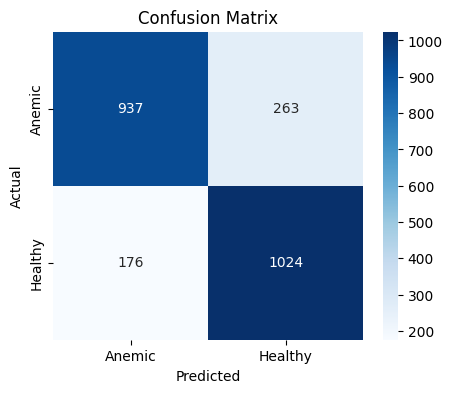

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Anemic", "Healthy"],
    yticklabels=["Anemic", "Healthy"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [25]:
# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=["Anemic", "Healthy"]
))

              precision    recall  f1-score   support

      Anemic       0.84      0.78      0.81      1200
     Healthy       0.80      0.85      0.82      1200

    accuracy                           0.82      2400
   macro avg       0.82      0.82      0.82      2400
weighted avg       0.82      0.82      0.82      2400



In [30]:
# Predicted probabilities (already computed earlier, but recompute safely)
val_gen.reset()
y_probs = model.predict(val_gen).ravel()
y_true = val_gen.classes

300/300 ━━━━━━━━━━━━━━━━━━━━ 62s 206ms/step


In [31]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

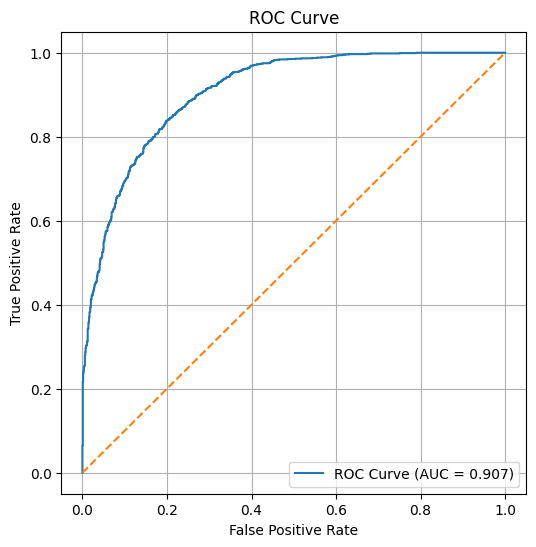

In [32]:
# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [27]:
img_path = val_gen.filepaths[0]

img = keras.preprocessing.image.load_img(
    img_path, target_size=(IMG_SIZE, IMG_SIZE)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

In [33]:
base_model = model.get_layer("mobilenetv2_1.00_224")

for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Last conv layer:", layer.name)
        break


Last conv layer: Conv_1


In [40]:
print(img_array.shape)
print(img_array.dtype)


(1, 224, 224, 3)
float32


In [42]:
_ = model(img_array)

In [43]:
mobilenet = model.get_layer("mobilenetv2_1.00_224")

In [44]:
print([l.name for l in mobilenet.layers][-10:])

['block_16_expand_BN', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_BN', 'block_16_depthwise_relu', 'block_16_project', 'block_16_project_BN', 'Conv_1', 'Conv_1_bn', 'out_relu']


In [45]:
print([l.name for l in mobilenet.layers][-10:])

['block_16_expand_BN', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_BN', 'block_16_depthwise_relu', 'block_16_project', 'block_16_project_BN', 'Conv_1', 'Conv_1_bn', 'out_relu']


In [48]:
print(model)

<Sequential name=sequential, built=True>


In [50]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2

# Input
inputs = Input(shape=(224, 224, 3))

# Backbone
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=inputs
)
base_model.trainable = False

# Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

# FINAL model (this fixes everything)
model = Model(inputs, outputs)


C:\Users\mehka\AppData\Local\Temp\ipykernel_25652\1953595202.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [51]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [53]:
model = tf.keras.models.load_model("best_model.h5", compile=False)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [59]:
print(model.input)
print(model.output)

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1682>
<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1683>


In [55]:
_ = model(tf.zeros((1, 224, 224, 3)))


In [57]:
loaded_model = tf.keras.models.load_model("best_model.h5", compile=False)

In [58]:
from tensorflow.keras import Input, Model

inputs = Input(shape=(224, 224, 3))
outputs = loaded_model(inputs)
model = Model(inputs, outputs)

In [65]:
seq = model.get_layer("sequential")

In [66]:
mobilenet = seq.get_layer("mobilenetv2_1.00_224")

In [69]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2

inputs = Input(shape=(224, 224, 3))

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=inputs
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

gradcam_model = Model(inputs, outputs)


C:\Users\mehka\AppData\Local\Temp\ipykernel_25652\181953240.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [70]:
gradcam_model.set_weights(model.get_weights())


In [71]:
gradcam_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [72]:
def make_gradcam_heatmap(img_array, model):
    last_conv_layer = model.get_layer("Conv_1")

    grad_model = Model(
        model.input,
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()


In [73]:
heatmap = make_gradcam_heatmap(img_array, gradcam_model)


In [77]:
import cv2

def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img
    return np.uint8(superimposed_img)


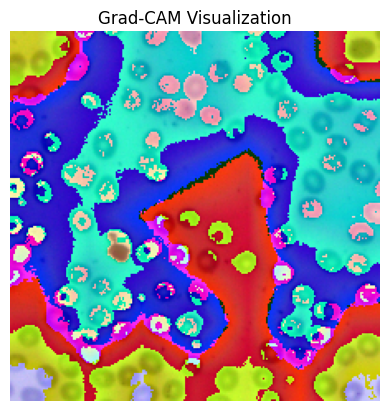

In [78]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

superimposed_img = overlay_gradcam(img, heatmap)

plt.figure()
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()


In [ ]:
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

In [80]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img = img.astype("float32") / 255.0

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_colored = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

heatmap_colored = heatmap_colored.astype("float32") / 255.0

superimposed_img = 0.4 * heatmap_colored + img
superimposed_img = np.clip(superimposed_img, 0, 1)


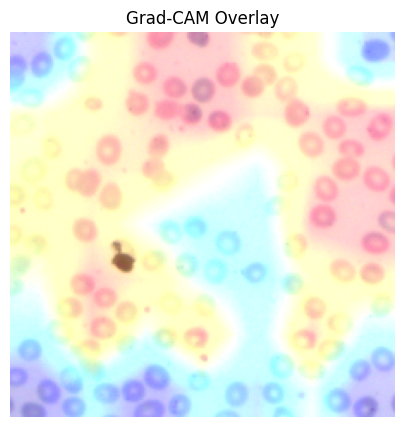

In [81]:
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.show()
